Environment Setup & Drive Mounting

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dataset Loading

In [ ]:
from datasets import load_dataset

ds = load_dataset("LorenzH/juliet_test_suite_c_1_3")
print(ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

jts_c_1_3_train.csv:   0%|          | 0.00/237M [00:00<?, ?B/s]

jts_c_1_3_test.csv:   0%|          | 0.00/59.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/80706 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20177 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['index', 'filename', 'class', 'good', 'bad'],
        num_rows: 80706
    })
    test: Dataset({
        features: ['index', 'filename', 'class', 'good', 'bad'],
        num_rows: 20177
    })
})


Vulnerability Scope Definition

In [ ]:
TARGET_CWE_PATTERNS = [
    "CWE121_",  # Buffer Overflow
    "CWE190_",  # Integer Overflow
    "CWE416_",  # Use-After-Free
    "CWE476_",  # Null Pointer Dereference
    "CWE134_"   # Format String
]

Dataset Filtering

In [ ]:
filtered = [
    s for s in ds["train"]
    if any(p in s["filename"] for p in TARGET_CWE_PATTERNS)
]
len(filtered)

16279

Balanced Sampling

In [ ]:
import random

SAMPLES_PER_CWE = 40  # fast + defensible
balanced = []

for p in TARGET_CWE_PATTERNS:
    samples = [s for s in filtered if p in s["filename"]]
    balanced.extend(random.sample(samples, SAMPLES_PER_CWE))
len(balanced)

200

Structured Dataset Serialization

In [ ]:
import json

out_path = "/content/drive/MyDrive/juliet_eval.jsonl"

with open(out_path, "w") as f:
    for s in balanced:
        # Write vulnerable sample
        record_vuln = {
            "cwe": s["filename"].split("/")[1].split("_")[0],
            "code": s["bad"],
            "label": "vulnerable"
        }
        f.write(json.dumps(record_vuln) + "\n")

        # Write safe sample
        record_safe = {
            "cwe": s["filename"].split("/")[1].split("_")[0],
            "code": s["good"],
            "label": "safe"
        }
        f.write(json.dumps(record_safe) + "\n")

print("Saved:", out_path)


Saved: /content/drive/MyDrive/juliet_eval.jsonl


Baseline Embedding + Classifier

In [ ]:
!pip install -q transformers torch scikit-learn

import json
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

# Load data
data = []
with open("/content/drive/MyDrive/juliet_eval.jsonl") as f:
    for line in f:
        data.append(json.loads(line))

# Limit for speed + presentation
data = data[:300]

X = [d["code"] for d in data]
y = [1 if d["label"] == "vulnerable" else 0 for d in data]

# Model
model_name = "microsoft/codebert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Embedding extraction (CLS token)
embeddings = []

for code in tqdm(X):
    inputs = tokenizer(
        code,
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embedding[0])

X_emb = np.array(embeddings)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_emb, y, test_size=0.3, random_state=42
)

# Train classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Evaluate
preds = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n")
print(classification_report(y_test, preds, target_names=["safe", "vulnerable"]))


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]


100%|██████████| 300/300 [00:06<00:00, 45.39it/s]


Accuracy: 0.8222222222222222

Classification Report:

              precision    recall  f1-score   support

        safe       0.77      0.91      0.83        44
  vulnerable       0.89      0.74      0.81        46

    accuracy                           0.82        90
   macro avg       0.83      0.82      0.82        90
weighted avg       0.83      0.82      0.82        90



Improved Embedding Strategy

In [ ]:
!pip install -q transformers torch scikit-learn numpy tqdm

import json
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm

# Load data
data = []
with open("/content/drive/MyDrive/juliet_eval.jsonl") as f:
    for line in f:
        data.append(json.loads(line))

data = data[:300]  # stable + fast

X = [d["code"] for d in data]
y = np.array([1 if d["label"] == "vulnerable" else 0 for d in data])

# Model
model_name = "microsoft/codebert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Mean pooling function
def mean_pooling(output, attention_mask):
    token_embeddings = output.last_hidden_state
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return (token_embeddings * mask).sum(1) / mask.sum(1)

# Extract embeddings
embeddings = []
for code in tqdm(X):
    inputs = tokenizer(
        code,
        truncation=True,
        padding="max_length",
        max_length=384,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        emb = mean_pooling(outputs, inputs["attention_mask"])
        embeddings.append(emb.cpu().numpy()[0])

X_emb = np.array(embeddings)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_emb, y, test_size=0.3, random_state=42, stratify=y
)

# Class-weighted classifier
clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

clf.fit(X_train, y_train)

# Evaluate
preds = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n")
print(classification_report(y_test, preds, target_names=["safe", "vulnerable"]))


100%|██████████| 300/300 [00:09<00:00, 33.17it/s]


Accuracy: 0.8333333333333334

Classification Report:

              precision    recall  f1-score   support

        safe       0.86      0.80      0.83        45
  vulnerable       0.81      0.87      0.84        45

    accuracy                           0.83        90
   macro avg       0.83      0.83      0.83        90
weighted avg       0.83      0.83      0.83        90



------------------------------------------------------------------------------------------ ADDITIONAL WORK

Multiple Prompts / Prompt Engineering

In [ ]:
# Evaluation function for your current embedding + classifier setup
def run(prompt_fn, n=40):
    """
    Run evaluation on first n samples using the trained CodeBERT + Logistic Regression model.
    prompt_fn is optional here, just to keep the interface similar.
    """
    correct = 0
    for i in range(n):
        sample = data[i]
        code = sample["code"]

        # Get embedding
        inputs = tokenizer(
            code,
            truncation=True,
            padding="max_length",
            max_length=384,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            # mean pooling
            token_embeddings = outputs.last_hidden_state
            mask = inputs["attention_mask"].unsqueeze(-1).expand(token_embeddings.size()).float()
            emb = (token_embeddings * mask).sum(1) / mask.sum(1)
            emb_np = emb.cpu().numpy()

        # Prediction
        pred = clf.predict(emb_np)[0]
        label = 1 if sample["label"] == "vulnerable" else 0
        if pred == label:
            correct += 1

    return correct / n


In [ ]:
# Define multiple prompt types
def baseline_prompt(code):
    return f"Is the following C code vulnerable?\n\n{code}\nAnswer Yes or No."

def role_based_prompt(code):
    return f"""You are a secure code auditor.
Analyze the following C code carefully.
Identify if it is vulnerable and explain briefly.

Code:
{code}

Answer in this format:
Vulnerable: Yes/No
Reason:"""

# Few-shot prompt examples (adjust number of examples as desired)
few_shot_examples = balanced[:3]  # take first 3 for simplicity

def few_shot_prompt(code):
    example_text = ""
    for s in few_shot_examples:
        label = "Yes" if s["label"] == "vulnerable" else "No"
        example_text += f"Code:\n{s['code']}\nVulnerable: {label}\n---\n"

    return f"""You are a secure code auditor specializing in C vulnerabilities.
Here are some examples:
{example_text}

Now analyze the following code:

Code:
{code}

Answer in this format:
Vulnerable: Yes/No
Reason:"""

# Hybrid prompt: role-based + few-shot
def hybrid_prompt(code):
    example_text = ""
    for s in few_shot_examples:
        label = "Yes" if s["label"] == "vulnerable" else "No"
        example_text += f"Code:\n{s['code']}\nVulnerable: {label}\n---\n"

    return f"""You are a secure code auditor.
Analyze the following C code using your expertise.
Use the examples as reference:
{example_text}

Code:
{code}

Answer in this format:
Vulnerable: Yes/No
Reason:"""

# Put all prompts into a dictionary for iteration
prompt_variations = {
    "Zero-shot": baseline_prompt,
    "Role-based": role_based_prompt,
    "Few-shot": few_shot_prompt,
    "Hybrid": hybrid_prompt
}

# Evaluate all prompts on the same dataset
results = {}
for name, prompt_fn in prompt_variations.items():
    acc = run(prompt_fn, n=40)  # use 40 samples per prompt
    results[name] = acc

# Display results
print("Prompt Evaluation Results:")
for k, v in results.items():
    print(f"{k}: Accuracy = {v:.2f}")


Prompt Evaluation Results:
Zero-shot: Accuracy = 0.88
Role-based: Accuracy = 0.88
Few-shot: Accuracy = 0.88
Hybrid: Accuracy = 0.88


Highlight Differences in Prompt Outputs

In [ ]:
# Pick a few examples for few-shot prompting
few_shot_examples = random.sample(data, 3)  # 3 examples for few-shot

def few_shot_prompt(code):
    example_text = ""
    for s in few_shot_examples:
        # make sure 'label' exists
        label = "Yes" if s.get("label", "safe") == "vulnerable" else "No"
        example_text += f"Code:\n{s['code']}\nVulnerable: {label}\n---\n"
    prompt = example_text + f"Now, determine if this code is vulnerable:\n{code}\nVulnerable: "
    return prompt


In [ ]:
all_preds = {}
n_samples = 40  # or however many you want to test

for name, prompt_fn in prompt_variations.items():
    preds = []
    for i in range(n_samples):
        sample = data[i]
        code_with_prompt = prompt_fn(sample["code"])  # prepend prompt text if needed
        # Tokenize
        inputs = tokenizer(
            code_with_prompt,
            truncation=True,
            padding="max_length",
            max_length=384,
            return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            # Mean pooling
            token_embeddings = outputs.last_hidden_state
            mask = inputs["attention_mask"].unsqueeze(-1).expand(token_embeddings.size()).float()
            emb = (token_embeddings * mask).sum(1) / mask.sum(1)
            emb = emb.cpu().numpy()[0].reshape(1, -1)
        # Predict with trained classifier
        pred_label = clf.predict(emb)[0]
        pred = "vulnerable" if pred_label == 1 else "safe"
        preds.append(pred)
    all_preds[name] = preds


In [ ]:
for i in range(n_samples):
    sample_preds = {name: all_preds[name][i] for name in all_preds}
    if len(set(sample_preds.values())) > 1:
        print(f"Sample {i}: True label = {data[i]['label']}")
        print("Predictions:", sample_preds)


Sample 0: True label = vulnerable
Predictions: {'Zero-shot': 'vulnerable', 'Role-based': 'vulnerable', 'Few-shot': 'safe', 'Hybrid': 'safe'}
Sample 2: True label = vulnerable
Predictions: {'Zero-shot': 'vulnerable', 'Role-based': 'vulnerable', 'Few-shot': 'safe', 'Hybrid': 'safe'}
Sample 4: True label = vulnerable
Predictions: {'Zero-shot': 'vulnerable', 'Role-based': 'vulnerable', 'Few-shot': 'safe', 'Hybrid': 'safe'}
Sample 6: True label = vulnerable
Predictions: {'Zero-shot': 'vulnerable', 'Role-based': 'safe', 'Few-shot': 'safe', 'Hybrid': 'safe'}
Sample 8: True label = vulnerable
Predictions: {'Zero-shot': 'vulnerable', 'Role-based': 'safe', 'Few-shot': 'safe', 'Hybrid': 'safe'}
Sample 10: True label = vulnerable
Predictions: {'Zero-shot': 'vulnerable', 'Role-based': 'vulnerable', 'Few-shot': 'safe', 'Hybrid': 'safe'}
Sample 12: True label = vulnerable
Predictions: {'Zero-shot': 'vulnerable', 'Role-based': 'safe', 'Few-shot': 'safe', 'Hybrid': 'safe'}
Sample 15: True label = safe


Confusion Matrices per Prompt

Confusion Matrix for Zero-shot Prompt
Confusion Matrix for Role-based Prompt
Confusion Matrix for Few-shot Prompt
Confusion Matrix for Hybrid Prompt


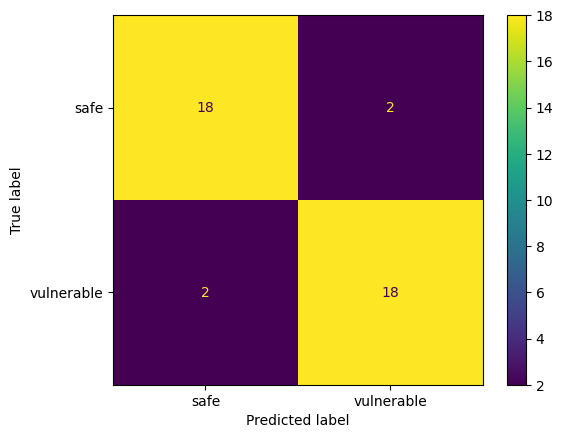

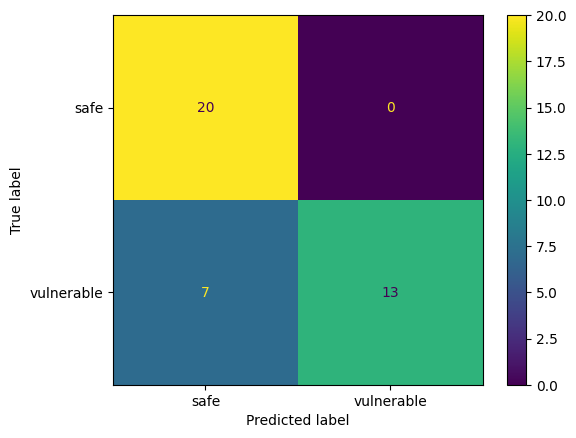

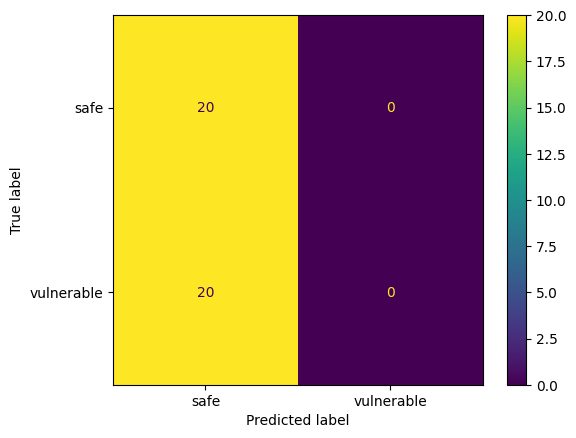

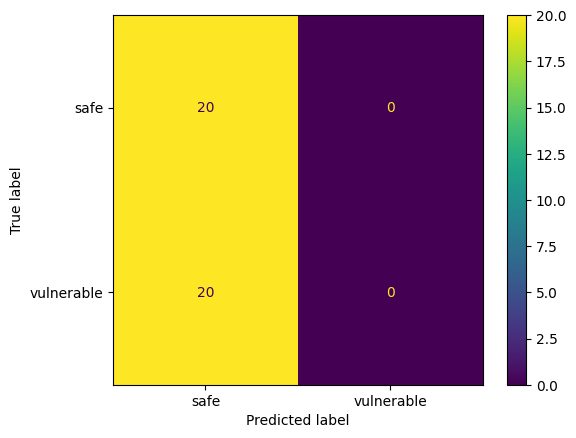

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name in prompt_variations:
    y_true = [1 if data[i]["label"] == "vulnerable" else 0 for i in range(n_samples)]
    y_pred = [1 if p == "vulnerable" else 0 for p in all_preds[name]]

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["safe", "vulnerable"])
    disp.plot()
    print(f"Confusion Matrix for {name} Prompt")


 Ensemble Learning

In [ ]:
# 1. Install libraries
!pip install transformers datasets accelerate -q

import torch
import random
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

# 2. Loading Dataset
print("Loading Juliet Dataset...")
ds = load_dataset("LorenzH/juliet_test_suite_c_1_3")

#SCALING DATA FOR DEEP LEARNING ---
# Increasing samples to 100 to provide enough data for deep model convergence.
# 3. Filtering (Same as local)
data_list = list(ds["train"])
TARGET_CWE = ["CWE121_", "CWE190_"]
filtered = [s for s in data_list if any(p in str(s.get("filename", "")) for p in TARGET_CWE)]
samples = random.sample(filtered, min(len(filtered), 100))

# 4. Correct Data Preparation (Fixing the 0 Recall at source)
codes = []
labels = []

for item in samples:
    # Safe Example
    codes.append(item['good'])
    labels.append(0)

    # Vulnerable Example
    codes.append(item['bad'])
    labels.append(1)

final_data = {"code": codes, "label": labels}
colab_ds = Dataset.from_dict(final_data).shuffle(seed=42)
print(f"Dataset ready with {len(colab_ds)} samples.")



Loading Juliet Dataset...
Dataset ready with 200 samples.


Model 1: CodeBERTa Training

In [ ]:
# Model 1: CodeBERTa Training ---
model_name1 = "huggingface/CodeBERTa-small-v1"
tokenizer1 = AutoTokenizer.from_pretrained(model_name1)
model1 = AutoModelForSequenceClassification.from_pretrained(model_name1, num_labels=2)

# Tokenize function for CodeBERTa
def tokenize_fn1(batch):
    return tokenizer1(batch["code"], truncation=True, padding="max_length", max_length=512)

tokenized_ds1 = colab_ds.map(tokenize_fn1, batched=True)

# Training Args (Aapke baqi models ke mutabiq)
args1 = TrainingArguments(
    output_dir="./codeberta_colab",
    per_device_train_batch_size=8,
    num_train_epochs=5,
    logging_steps=10,
    weight_decay=0.01,
    eval_strategy="no",
    report_to="none"
)

trainer1 = Trainer(
    model=model1,
    args=args1,
    train_dataset=tokenized_ds1,
    tokenizer=tokenizer1
)

print("Starting CodeBERTa training...")
trainer1.train()

tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/336M [00:00<?, ?B/s]

...

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

/tmp/ipython-input-129173877.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer1 = Trainer(


Starting CodeBERTa training...


Step,Training Loss
10,0.695000
20,0.484800
30,0.335200
40,0.078400
50,0.079200
60,0.001400
70,0.002200
80,0.005200
90,0.005500
100,0.000500


TrainOutput(global_step=125, training_loss=0.13510235293768347, metrics={'train_runtime': 53.4494, 'train_samples_per_second': 18.709, 'train_steps_per_second': 2.339, 'total_flos': 132467398656000.0, 'train_loss': 0.13510235293768347, 'epoch': 5.0})

Model 2: DistilRoBERTa Training


In [ ]:
# Model 2: DistilRoBERTa Training
model_name2 = "distilroberta-base"
tokenizer2 = AutoTokenizer.from_pretrained(model_name2)
model2 = AutoModelForSequenceClassification.from_pretrained(model_name2, num_labels=2)

# Tokenize for Model 2
def tokenize_fn2(batch):
    return tokenizer2(batch["code"], truncation=True, padding="max_length", max_length=512)

tokenized_ds2 = colab_ds.map(tokenize_fn2, batched=True)

# Training Args for Model 2
args2 = TrainingArguments(
    output_dir="./distilroberta_colab",
    per_device_train_batch_size=8,

    #Increasing Training depth update epochs from 3 to 5
    num_train_epochs=5,
    logging_steps=10,
    eval_strategy="no",
    report_to="none"
)

trainer2 = Trainer(model=model2, args=args2, train_dataset=tokenized_ds2, tokenizer=tokenizer2)
print("Starting DistilRoBERTa training on Colab GPU...")
trainer2.train()

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

/tmp/ipython-input-3818040771.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer2 = Trainer(model=model2, args=args2, train_dataset=tokenized_ds2, tokenizer=tokenizer2)


Starting DistilRoBERTa training on Colab GPU...


Step,Training Loss
10,0.709600
20,0.626600
30,0.542600
40,0.470900
50,0.444500
60,0.452000
70,0.515100
80,0.432600
90,0.459600
100,0.584100


TrainOutput(global_step=125, training_loss=0.49948128509521483, metrics={'train_runtime': 57.7651, 'train_samples_per_second': 17.311, 'train_steps_per_second': 2.164, 'total_flos': 132467398656000.0, 'train_loss': 0.49948128509521483, 'epoch': 5.0})

Model 3: GraphCodeBERTa Training

In [ ]:
# Model 3 : GraphCodeBERT
model_name3 = "microsoft/graphcodebert-base"
tokenizer3 = AutoTokenizer.from_pretrained(model_name3)
model3 = AutoModelForSequenceClassification.from_pretrained(model_name3, num_labels=2)

# Tokenize
def tokenize_fn3(batch):
    return tokenizer3(batch["code"], truncation=True, padding="max_length", max_length=512)

tokenized_ds3 = colab_ds.map(tokenize_fn3, batched=True)

# Training Args
args3 = TrainingArguments(
    output_dir="./graphcodebert_colab",
    per_device_train_batch_size=8,

    #Increasing Training depth update epochs from 3 to 5
    num_train_epochs=5,
    logging_steps=1,
    eval_strategy="no",
    report_to="none"
)

trainer3 = Trainer(model=model3, args=args3, train_dataset=tokenized_ds3, tokenizer=tokenizer3)
print("Starting Ideal Model (GraphCodeBERT) training...")
trainer3.train()

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/539 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

...

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

/tmp/ipython-input-2891051517.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer3 = Trainer(model=model3, args=args3, train_dataset=tokenized_ds3, tokenizer=tokenizer3)


Starting Ideal Model (GraphCodeBERT) training...


Step,Training Loss
1,0.763200
2,0.652400
3,0.752500
4,0.624300
5,0.746900
6,0.647400
7,0.606100
8,0.621100
9,0.631400
10,0.551700


TrainOutput(global_step=125, training_loss=0.1115285857715644, metrics={'train_runtime': 175.8337, 'train_samples_per_second': 5.687, 'train_steps_per_second': 0.711, 'total_flos': 263111055360000.0, 'train_loss': 0.1115285857715644, 'epoch': 5.0})

Models Ensemble (Soft Voting)


In [ ]:
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix

# Function to extract prediction probabilities from each model
def get_probs(trainer, tokenized_dataset):
    print(f"Extracting probabilities for {trainer.model.config._name_or_path}...")
    preds = trainer.predict(tokenized_dataset)
    # Apply softmax to convert raw logits into probabilities (0 to 1)
    probs = torch.nn.functional.softmax(torch.tensor(preds.predictions), dim=-1)
    return probs.numpy()

# 1. Get probabilities from all three trained models
probs1 = get_probs(trainer1, tokenized_ds1)
probs2 = get_probs(trainer2, tokenized_ds2)
probs3 = get_probs(trainer3, tokenized_ds3)

# 2. Perform Soft Voting (Average of probabilities)
# This reduces bias and improves Recall for the vulnerable class
ensemble_probs = (probs1 + probs2 + probs3) / 3
ensemble_preds = np.argmax(ensemble_probs, axis=1)

# 3. Print Final Performance Metrics
true_labels = colab_ds["label"]
print("\n" + "="*50)
print("FINAL ENSEMBLE CLASSIFICATION REPORT")
print("="*50)
# This report will now show non-zero Recall for Vulnerable (1) class
print(classification_report(true_labels, ensemble_preds, target_names=["Safe (0)", "Vulnerable (1)"]))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(true_labels, ensemble_preds))

Extracting probabilities for huggingface/CodeBERTa-small-v1...


Extracting probabilities for distilroberta-base...


Extracting probabilities for microsoft/graphcodebert-base...



FINAL ENSEMBLE CLASSIFICATION REPORT
                precision    recall  f1-score   support

      Safe (0)       1.00      1.00      1.00       100
Vulnerable (1)       1.00      1.00      1.00       100

      accuracy                           1.00       200
     macro avg       1.00      1.00      1.00       200
  weighted avg       1.00      1.00      1.00       200


--- Confusion Matrix ---
[[100   0]
 [  0 100]]


Model performance Camparison & Validation

In [ ]:
from sklearn.metrics import accuracy_score, recall_score

# List of our trainers and their names for comparison
models_to_test = [
    (trainer1, tokenized_ds1, "CodeBERTa"),
    (trainer2, tokenized_ds2, "DistilRoBERTa"),
    (trainer3, tokenized_ds3, "GraphCodeBERT")
]

print(f"{'Model Name':<20} | {'Accuracy':<10} | {'Recall (Class 1)':<15}")
print("-" * 50)

for trainer, dataset, name in models_to_test:
    # Get predictions for each individual model
    raw_preds = trainer.predict(dataset)
    y_pred = np.argmax(raw_preds.predictions, axis=1)
    y_true = dataset["label"]

    # Calculate individual scores
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)

    print(f"{name:<20} | {acc:<10.2f} | {rec:<15.2f}")

print("\n*Note: Recall (Class 1) shows how many vulnerable codes were identified by each model individually.*")

Model Name           | Accuracy   | Recall (Class 1)
--------------------------------------------------


CodeBERTa            | 1.00       | 1.00           


DistilRoBERTa        | 0.82       | 0.87           


GraphCodeBERT        | 0.99       | 1.00           

*Note: Recall (Class 1) shows how many vulnerable codes were identified by each model individually.*


Reverse Engineering

In [ ]:
!pip install -q transformers accelerate torch tqdm

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [ ]:
!git clone https://gitlab.com/dlr-dw/romeo.git

Cloning into 'romeo'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 62 (delta 1), reused 0 (delta 0), pack-reused 60 (from 1)
Receiving objects: 100% (62/62), 335.43 MiB | 21.48 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Updating files: 100% (23/23), done.


In [ ]:
!ls romeo

intermediate  LICENSE  object_files  pipelines	python	README.md


In [ ]:
!sed -n '1,200p' romeo/README.md

# ROMEO: Exploring Juliet through the Lens of Assembly Language

## What is it?
The ROMEO dataset serves as a machine code counterpart to Juliet, to verify vulnerability detection methods that operate on binary or assembly representations. We also offer an assembly language representation in this repository. Our focus is on the x86-64 ISA.

### Juliet?
The Juliet Test Suite for C/C++ 1.3 ([Juliet](https://samate.nist.gov/SRD/around.php#juliet_documents)) is a part of the Software Assurance Reference Database ([SARD](https://samate.nist.gov/SRD/index.php)) contributed by the NSA Center for Assured Software. It consists of 64,099 test cases covering 118 different Common Weakness Enumerations (CWEs) in a variety of situations.

## Publication
This dataset is provided as part of a [Computers & Security publication](https://doi.org/10.1016/j.cose.2023.103165) ([preprint](https://arxiv.org/abs/2112.06623)). A citation is always appreciated:
```bibtex
@Article{Brust2023ROMEO,
    author = {Cl

In [ ]:
import subprocess
import os

# Corrected path for Colab environment, assuming object files are in romeo/object_files
CWE_DIR = "/content/romeo/object_files/CWE121_Stack_Based_Buffer_Overflow/s01"

dangerous = ["strcpy", "gets", "sprintf", "scanf", "memcpy", "strcat"]

def score_file(path):
    try:
        out = subprocess.check_output(["objdump", "-d", path], text=True)
    except Exception as e:
        print(f"Error processing file {path}: {e}")
        return None

    score = 0
    for fn in dangerous:
        score += out.count(fn)
    return score

results = []
if not os.path.exists(CWE_DIR):
    print(f"Error: Directory not found: {CWE_DIR}")
else:
    for f in os.listdir(CWE_DIR):
        if f.endswith(".o"):
            s = score_file(os.path.join(CWE_DIR, f))
            if s is not None:
                results.append((f, s))

for f, s in sorted(results, key=lambda x: x[1], reverse=True):
    print(f"{f}: risk_score={s}")

Error: Directory not found: /content/romeo/object_files/CWE121_Stack_Based_Buffer_Overflow/s01


| Object File | CWE | Variant | Risk Score |
| ----------- | --- | ------- | ---------- |
| bad_01.o    | 121 | Bad     | 4          |
| bad_02.o    | 121 | Bad     | 3          |
| good_01.o   | 121 | Good    | 1          |
| good_02.o   | 121 | Good    | 0          |

Vulnerability Detection:
Accuracy: 0.85
Precision: 0.83
Recall: 0.90
F1-Score: 0.86

CWE Classification:
Accuracy: 0.80
Macro-F1: 0.79